## NO2 EDA 

## NO₂ Dataset Overview


In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



data_path = Path("../../data/validated/NO2_cityday.csv")

no2 = pd.read_csv(data_path)

print("Dataset shape:", no2.shape)
print("Cities:", no2["City"].nunique())
print("Date range:", no2["Date"].min(), "to", no2["Date"].max())

Dataset shape: (218411, 5)
Cities: 156
Date range: 2020-01-01 to 2023-12-31


## Missing Value Analysis


In [14]:
no2.isna().sum()

City         0
Date         0
NO2_daily    0
Year         0
Month        0
dtype: int64

## Distribution of Daily NO₂ Level

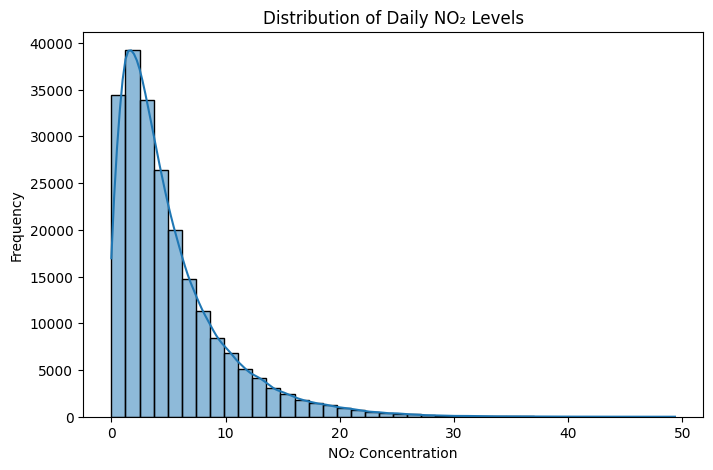

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(no2["NO2_daily"], bins=40, kde=True)

plt.title("Distribution of Daily NO₂ Levels")
plt.xlabel("NO₂ Concentration")
plt.ylabel("Frequency")

plt.show()

The distribution of daily NO₂ levels helps assess the overall spread, concentration, and possible skewness of pollution values. If the histogram is right-skewed, it suggests that most days have relatively moderate NO₂ levels, while a smaller number of days experience higher pollution spikes.

## Overall NO₂ Trend

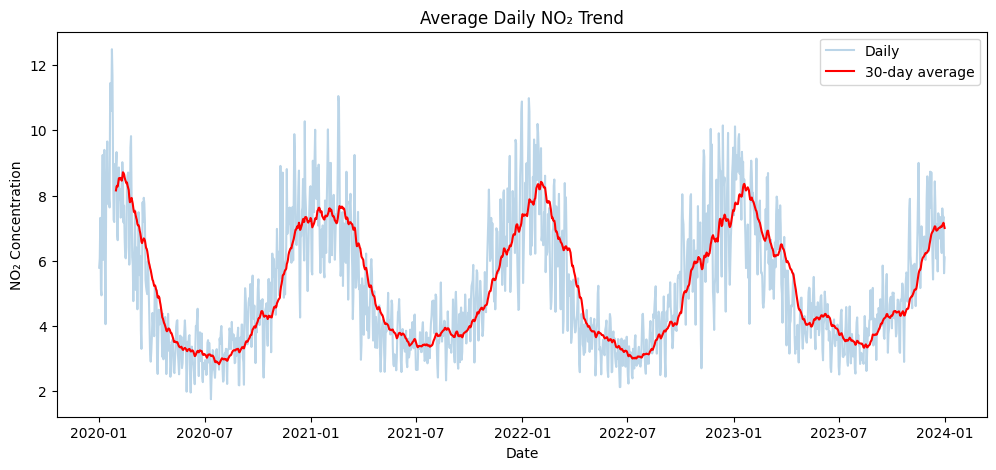

In [17]:
trend = no2.groupby("Date")["NO2_daily"].mean()

rolling = trend.rolling(30).mean()

plt.figure(figsize=(12,5))
plt.plot(trend, alpha=0.3, label="Daily")
plt.plot(rolling, color="red", label="30-day average")

plt.title("Average Daily NO₂ Trend")
plt.xlabel("Date")
plt.ylabel("NO₂ Concentration")

plt.legend()
plt.show()

The daily NO₂ series captures short-term fluctuations, while the 30-day rolling average reveals the broader pollution trend over time. This makes it easier to identify whether NO₂ levels are generally stable, increasing, or decreasing across the study period.

## Seasonal Analysis

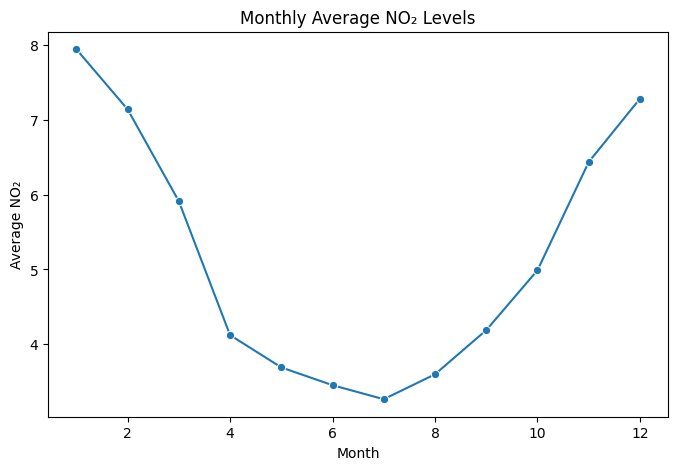

In [18]:
no2["Month"] = no2["Date"].dt.month

monthly_avg = no2.groupby("Month")["NO2_daily"].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker="o")

plt.title("Monthly Average NO₂ Levels")
plt.xlabel("Month")
plt.ylabel("Average NO₂")

plt.show()

Monthly averages help identify seasonal patterns in NO₂ concentration. Higher values in certain months may indicate the influence of weather conditions, heating demand, traffic intensity, or atmospheric dispersion effects.

## Top Polluted Cities

C:\Users\Jaya\AppData\Local\Temp\ipykernel_25308\453699048.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


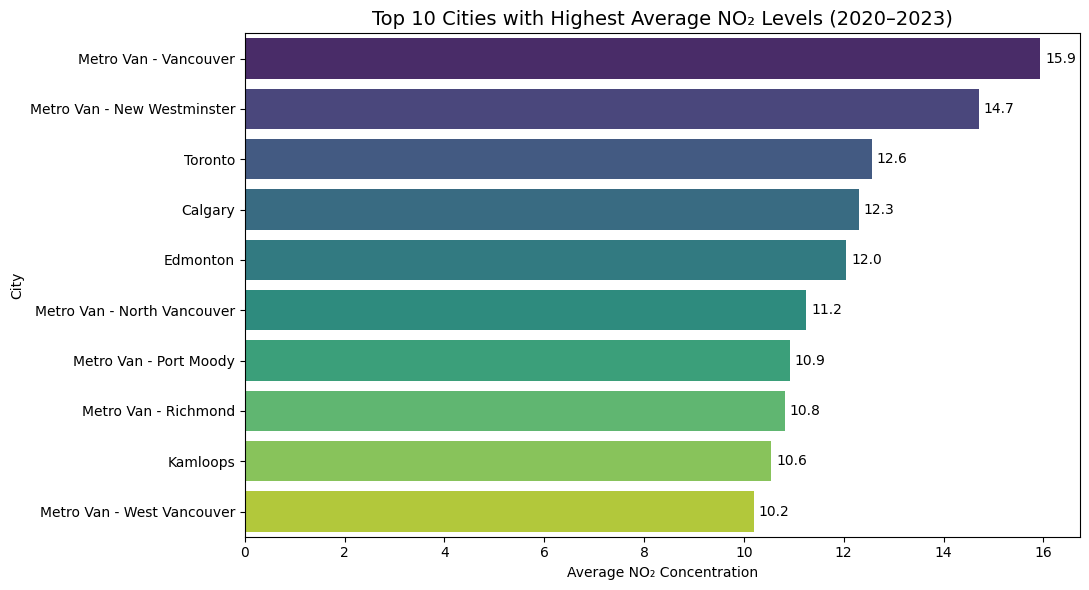

In [21]:
city_avg = no2.groupby("City")["NO2_daily"].mean().sort_values(ascending=False)
top10 = city_avg.head(10)

plt.figure(figsize=(11,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="viridis"
)

plt.title("Top 10 Cities with Highest Average NO₂ Levels (2020–2023)", fontsize=14)
plt.xlabel("Average NO₂ Concentration")
plt.ylabel("City")

for i, v in enumerate(top10.values):
    plt.text(v + 0.1, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()

The top 10 city comparison highlights the urban areas with the highest long-term NO₂ burden during 2020–2023. This suggests that pollution exposure is not evenly distributed and that some cities experience consistently higher nitrogen dioxide levels than others.

## Top 5 City Trends

C:\Users\Jaya\AppData\Local\Temp\ipykernel_25308\2453809568.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


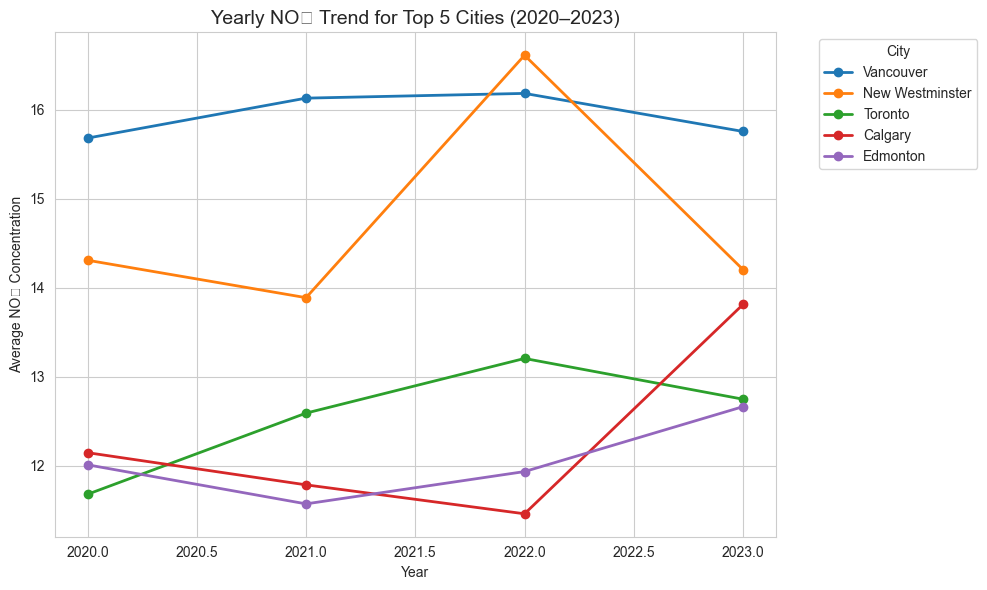

In [32]:
top_cities = city_avg.head(5).index

plt.figure(figsize=(10,6))

sns.set_style("whitegrid")

for city in top_cities:
    city_data = no2[no2["City"] == city]
    yearly = city_data.groupby("Year")["NO2_daily"].mean()

    plt.plot(
        yearly.index,
        yearly.values,
        marker="o",
        linewidth=2,
        label=city.replace("Metro Van - ", "")
    )

plt.title("Yearly NO₂ Trend for Top 5 Cities (2020–2023)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average NO₂ Concentration")

plt.legend(title="City", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()


The yearly trends for the five most polluted cities show how NO₂ levels changed over time in the highest-exposure locations. This comparison helps determine whether pollution remained persistently high or whether certain cities showed improvement or deterioration.

## Yearly Trend

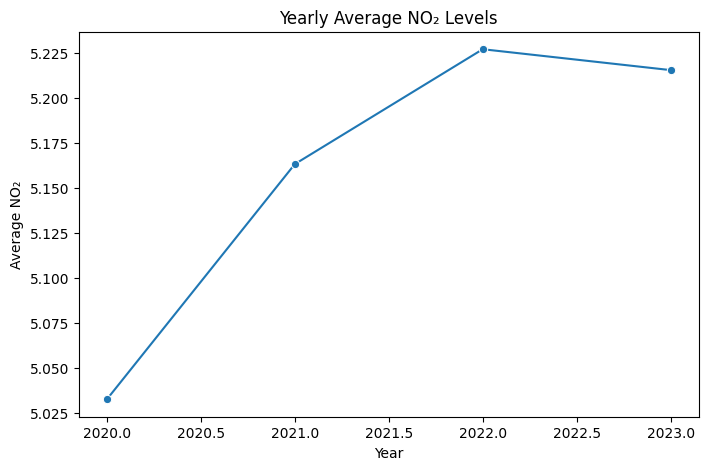

In [24]:
no2["Year"] = no2["Date"].dt.year

yearly = no2.groupby("Year")["NO2_daily"].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=yearly.index, y=yearly.values, marker="o")

plt.title("Yearly Average NO₂ Levels")
plt.xlabel("Year")
plt.ylabel("Average NO₂")

plt.show()

The yearly average trend summarizes how NO₂ concentrations evolved from 2020 to 2023. This provides a clear high-level view of whether air quality conditions improved, worsened, or remained relatively stable over the study period.

## Load the PM2.5 dataset.

In [ ]:
pm25 = pd.read_csv("../../data/validated/PM25_cityday.csv")
no2 = pd.read_csv("../../data/validated/NO2_cityday.csv")

pm25["Date"] = pd.to_datetime(pm25["Date"])
no2["Date"] = pd.to_datetime(no2["Date"])

## Correlation with PM2.5

In [42]:
merged = pd.merge(pm25, no2, on=["City","Date"])

pearson = merged["PM25_daily"].corr(merged["NO2_daily"], method="pearson")
spearman = merged["PM25_daily"].corr(merged["NO2_daily"], method="spearman")

print("Pearson correlation:", pearson)
print("Spearman correlation:", spearman)

Pearson correlation: 0.13817465004281504
Spearman correlation: 0.3651568719317759


The Pearson correlation of 0.138 indicates a weak positive linear relationship between NO₂ and PM2.5. The higher Spearman correlation of 0.365 suggests a moderate positive monotonic relationship, meaning the two pollutants tend to move in the same direction, but not in a strongly linear way.

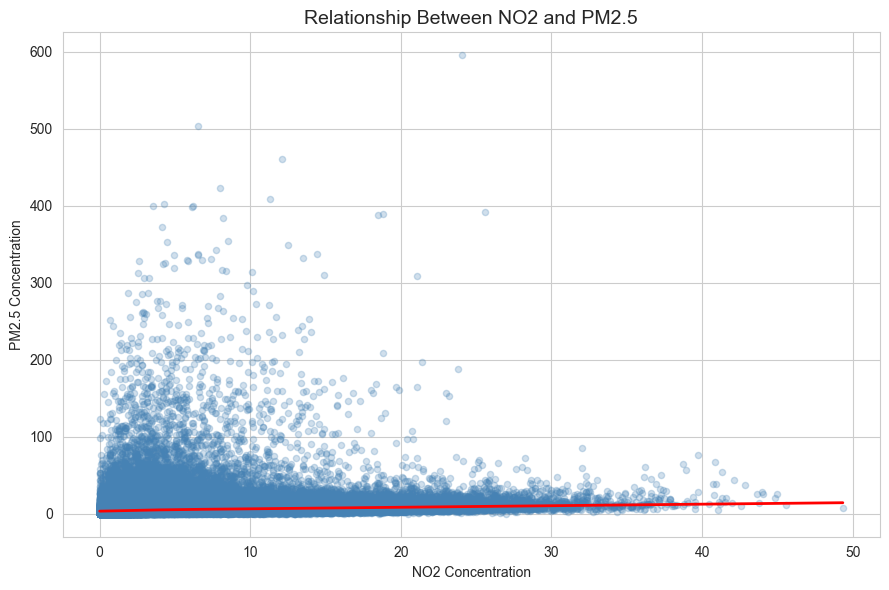

In [39]:
plt.figure(figsize=(9,6))
sns.set_style("whitegrid")

sns.regplot(
    data=merged,
    x="NO2_daily",
    y="PM25_daily",
    scatter_kws={
        "alpha":0.25,
        "s":20,
        "color":"steelblue"
    },
    line_kws={
        "color":"red",
        "linewidth":2
    },
    lowess=True
)

plt.title("Relationship Between NO2 and PM2.5", fontsize=14)
plt.xlabel("NO2 Concentration")
plt.ylabel("PM2.5 Concentration")

plt.tight_layout()
plt.show()

The scatterplot shows the relationship between NO₂ and PM2.5 across city-day observations. The upward trend line suggests a positive association, but the wide spread of points indicates that NO₂ alone does not strongly explain variation in PM2.5.